<a href="https://colab.research.google.com/github/Taniya1701/CSL701-CS06_Machine-Learning-Lab/blob/main/Experiments%20and%20Mini-Project/ML_EXP02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name: Taniya Anil Bhise  Roll No: CS06    Batch : CS01

Experiment No : 02

Aim:
 To implement a Simple Linear Regression model using Python and predict MPG from Horsepower using OLS.


Objectives:

* Understand SLR

* Load/preprocess dataset

* Perform EDA

* Compute OLS coefficients

* Evaluate with SSE, MSE, R²

* Visualize regression and residual plots


Software Requirements

* Python 3.x

* Jupyter/Colab/VS Code

* Libraries: pandas, numpy, matplotlib, seaborn


Theory :

Linear regression models the relationship between a target continuous variable Y and an input feature vector X using a linear equation:
yˆ=w0+w1x1

In matrix form, including the bias/intercept term X0=1:
yˆ=Xw

To find the optimal weight vector wˆ, the Ordinary Least Squares (OLS) method minimizes the Sum of Squared Errors (SSE) between actual target values y and predicted values yˆ:

SSE=i=1Nyi-yˆi2=y-XwTy-Xw

Solving for w analytically yields the normal equation:

wˆ=XTX-1XTy

Note: The inverse XTX-1 exists only if the matrix XTX is non-singular (i.e., its determinant is non-zero).


Algorithm:

1. Import libraries
2. Load Auto MPG dataset
3. Inspect and clean data
4. Select horsepower and mpg
5. Plot scatter graph
6. Add bias term
7. Compute correlation
8. Calculate OLS weights
9. Predict values
10. Compute residuals
11. Calculate SSE, MSE, R²
12. Plot regression and residual graphs
13. Interpret results.
14. Upload the google colab onto Git hub repository.


In [7]:
# Step 1: Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
# Step 2: Load Auto MPG Dataset
df = pd.read_csv("/content/auto-mpg (1).csv")

In [10]:
# Step 3: Inspect and Clean Data
print("First 5 Rows")
print(df.head())

print("\nDataset Information")
print(df.info())

print("\nMissing Values")
print(df.isnull().sum())

# Replace '?' with NaN (if present)
df.replace('?', np.nan, inplace=True)

# Convert horsepower to numeric
df['horsepower'] = pd.to_numeric(df['horsepower'])

# Remove missing values
df.dropna(inplace=True)

First 5 Rows
    mpg  cylinders  displacement horsepower  weight  acceleration  model year  \
0  18.0          8         307.0        130    3504          12.0          70   
1  15.0          8         350.0        165    3693          11.5          70   
2  18.0          8         318.0        150    3436          11.0          70   
3  16.0          8         304.0        150    3433          12.0          70   
4  17.0          8         302.0        140    3449          10.5          70   

   origin                   car name  
0       1  chevrolet chevelle malibu  
1       1          buick skylark 320  
2       1         plymouth satellite  
3       1              amc rebel sst  
4       1                ford torino  

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinde

In [11]:
# Step 4: Select Horsepower and MPG
X = df['horsepower'].values
Y = df['mpg'].values


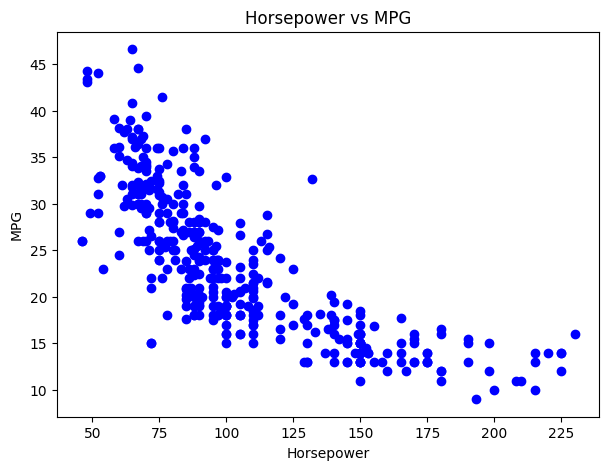

In [12]:
# Step 5: Plot Scatter Graph
plt.figure(figsize=(7,5))
plt.scatter(X, Y, color='blue')
plt.title("Horsepower vs MPG")
plt.xlabel("Horsepower")
plt.ylabel("MPG")
plt.show()


In [13]:
# Step 6: Add Bias Term
X_bias = np.column_stack((np.ones(len(X)), X))

In [14]:
# Step 7: Compute Correlation
correlation = np.corrcoef(X, Y)[0,1]
print("\nCorrelation:", correlation)


Correlation: -0.7784267838977756


In [15]:

# Step 8: Calculate OLS Weights
w = np.linalg.inv(X_bias.T @ X_bias) @ X_bias.T @ Y

print("\nOLS Coefficients")
print("Intercept (w0):", w[0])
print("Slope (w1):", w[1])


OLS Coefficients
Intercept (w0): 39.9358610211705
Slope (w1): -0.15784473335365387


In [16]:
# Step 9: Predict Values
Y_pred = X_bias @ w

In [17]:
# Step 10: Compute Residuals
residuals = Y - Y_pred

In [18]:

# Step 11: Calculate SSE, MSE and R²
SSE = np.sum(residuals**2)
MSE = np.mean(residuals**2)
R2 = 1 - (SSE / np.sum((Y - np.mean(Y))**2))

print("\nModel Evaluation")
print("SSE =", SSE)
print("MSE =", MSE)
print("R² =", R2)


Model Evaluation
SSE = 9385.915871932419
MSE = 23.943662938603108
R² = 0.6059482578894348


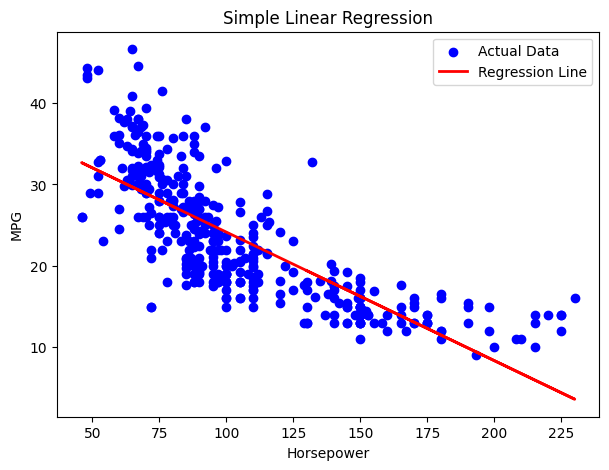

In [19]:
# Step 12: Plot Regression Line
plt.figure(figsize=(7,5))
plt.scatter(X, Y, color='blue', label='Actual Data')
plt.plot(X, Y_pred, color='red', linewidth=2, label='Regression Line')
plt.title("Simple Linear Regression")
plt.xlabel("Horsepower")
plt.ylabel("MPG")
plt.legend()
plt.show()

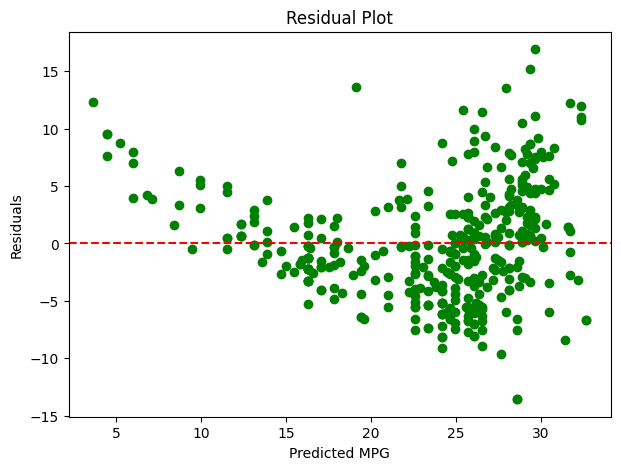

In [20]:
# Step 13: Plot Residual Graph
plt.figure(figsize=(7,5))
plt.scatter(Y_pred, residuals, color='green')
plt.axhline(y=0, color='red', linestyle='--')
plt.title("Residual Plot")
plt.xlabel("Predicted MPG")
plt.ylabel("Residuals")
plt.show()

In [21]:
# Step 14: Interpretation
print("\nInterpretation:")
if R2 > 0.8:
    print("Strong linear relationship between Horsepower and MPG.")
elif R2 > 0.5:
    print("Moderate linear relationship between Horsepower and MPG.")
else:
    print("Weak linear relationship between Horsepower and MPG.")


Interpretation:
Moderate linear relationship between Horsepower and MPG.


Conclusion:

The experiment successfully implemented Simple Linear Regression using OLS. Horsepower showed a negative relationship with MPG, and evaluation metrics demonstrated reasonable predictive performance.
